In [2]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from Exp1.Exp1 import perform_eda

Dataset: Spam Email Classification
Shape: (4601, 58)
------------------------------------------------------------
Column Types:
word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float6

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


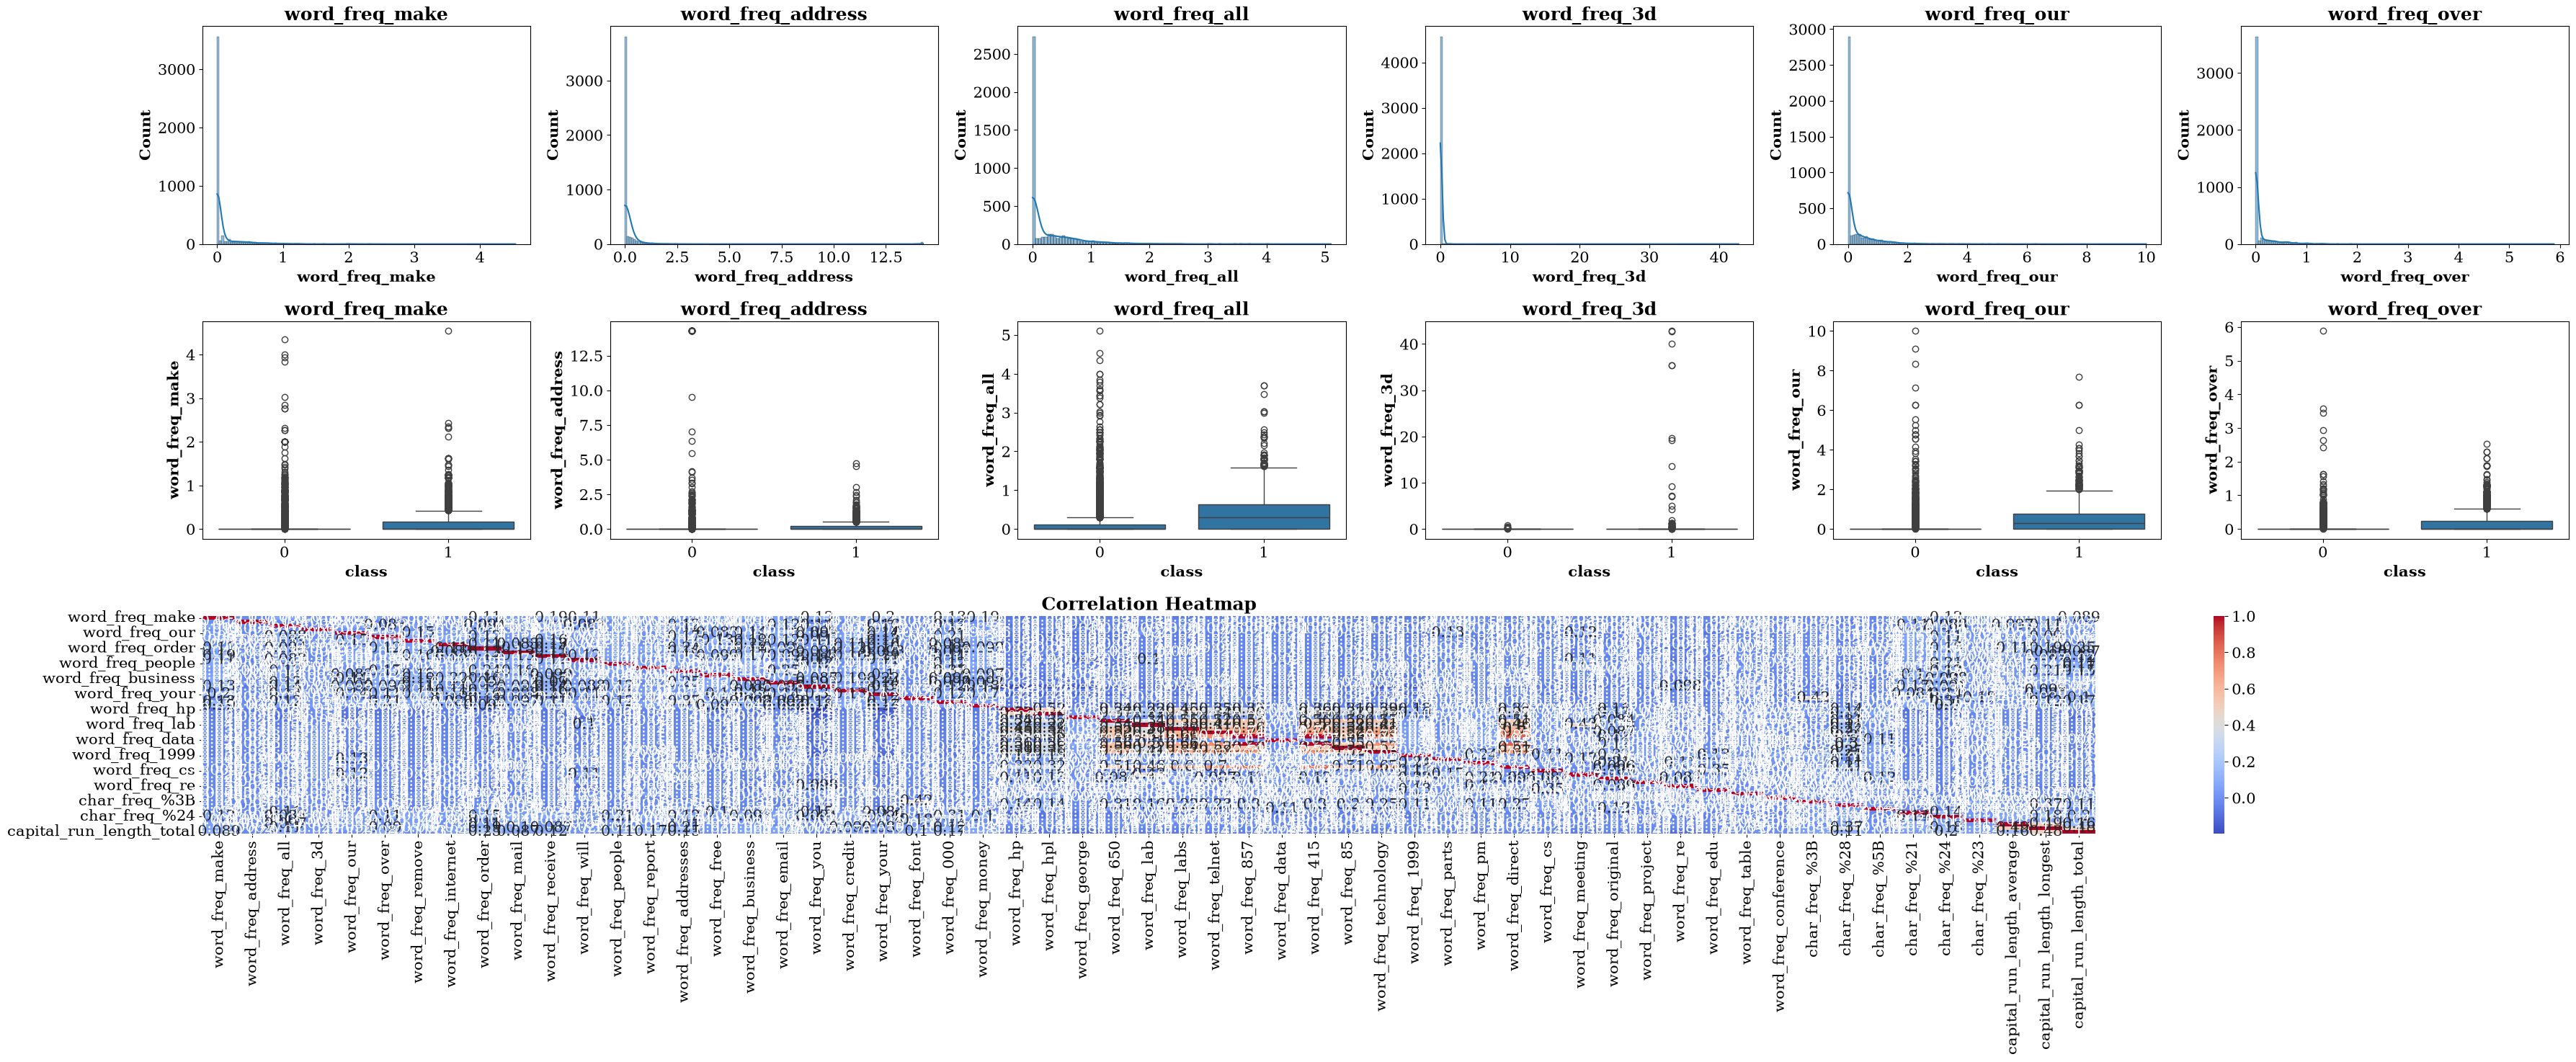

word_freq_make
Mean: 0.10455335796565964
Median: 0.0
Std Dev: 0.3053575620234699
Min: 0.0
Max: 4.54
Q1: 0.0
Q3: 0.0
Skewness: 5.675639163765851
Kurtosis: 49.30506415870118

word_freq_address
Mean: 0.21301456205172786
Median: 0.0
Std Dev: 1.2905751909453214
Min: 0.0
Max: 14.28
Q1: 0.0
Q3: 0.0
Skewness: 10.086810872543571
Kurtosis: 105.64747160937861

word_freq_all
Mean: 0.28065637904803303
Median: 0.0
Std Dev: 0.5041428838471842
Min: 0.0
Max: 5.1
Q1: 0.0
Q3: 0.42
Skewness: 3.0092485272970904
Kurtosis: 13.308743418467486

word_freq_3d
Mean: 0.06542490762877635
Median: 0.0
Std Dev: 1.3951513704928833
Min: 0.0
Max: 42.81
Q1: 0.0
Q3: 0.0
Skewness: 26.227744470347666
Kurtosis: 726.4515380990603

word_freq_our
Mean: 0.312223429689198
Median: 0.0
Std Dev: 0.672512769284666
Min: 0.0
Max: 10.0
Q1: 0.0
Q3: 0.38
Skewness: 4.747126114133084
Kurtosis: 37.94116889421045

word_freq_over
Mean: 0.09590089111062812
Median: 0.0
Std Dev: 0.2738240830098081
Min: 0.0
Max: 5.88
Q1: 0.0
Q3: 0.0
Skewness: 5.956

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [3]:
# Perform EDA
df = pd.read_csv("spambase_csv.csv")
# print(df['class'])
perform_eda(df, dataset_name="Spam Email Classification")


In [4]:
# Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


y = df['class']
x = df.drop(columns=['class'])

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)


In [5]:
# Multinomial NB Spam Classifier
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

mnb.fit(x_train, y_train)
y_pred_mnb = mnb.predict(x_test)

print("Multinomial Naive Bayes Performance:")
print("Classification Report: \n",classification_report(y_test, y_pred_mnb))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred_mnb))
print("Accuracy Score: ", accuracy_score(y_test, y_pred_mnb))

Multinomial Naive Bayes Performance:
Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       531
           1       0.76      0.72      0.74       390

    accuracy                           0.79       921
   macro avg       0.78      0.78      0.78       921
weighted avg       0.79      0.79      0.79       921

Confusion Matrix: 
 [[445  86]
 [111 279]]
Accuracy Score:  0.7861020629750272


In [6]:
# Normalizer
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [7]:
# Gaussian NB Spam Classifier
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(x_train, y_train)
y_pred_gnb = gnb.predict(x_test)

print("Gaussian Naive Bayes Performance:")
print("Classification Report: \n",classification_report(y_test, y_pred_gnb))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred_gnb))
print("Accuracy Score: ", accuracy_score(y_test, y_pred_gnb))

Gaussian Naive Bayes Performance:
Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.73      0.82       531
           1       0.72      0.95      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921

Confusion Matrix: 
 [[387 144]
 [ 21 369]]
Accuracy Score:  0.8208469055374593


In [8]:
# Bernoulli NB Spam Classifier
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()

bnb.fit(x_train, y_train)
y_pred_bnb = bnb.predict(x_test)

print("Bernoulli Naive Bayes Performance:")
print("Classification Report: \n",classification_report(y_test, y_pred_bnb))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred_bnb))
print("Accuracy Score: ", accuracy_score(y_test, y_pred_bnb))

Bernoulli Naive Bayes Performance:
Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.94      0.90       531
           1       0.91      0.80      0.85       390

    accuracy                           0.88       921
   macro avg       0.89      0.87      0.88       921
weighted avg       0.88      0.88      0.88       921

Confusion Matrix: 
 [[499  32]
 [ 78 312]]
Accuracy Score:  0.8805646036916395


In [9]:
# KNN Spam Classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

print("KNearest Neighbors Performance")
print("Classification Report: \n",classification_report(y_pred,y_test))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred))
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

KNearest Neighbors Performance
Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.80      0.82       562
           1       0.71      0.77      0.74       359

    accuracy                           0.79       921
   macro avg       0.78      0.79      0.78       921
weighted avg       0.79      0.79      0.79       921

Confusion Matrix: 
 [[450  81]
 [112 278]]
Accuracy Score:  0.7904451682953312


In [10]:
# KNN GridSearchCV Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(), 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(x_train_scaled, y_train)


print("--- Tuning Results ---")
print("Best Parameters: ", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}\n".format(grid_search.best_score_))

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled)

print("Best K Value: ",grid_search.best_params_['n_neighbors'])
print("KNN Performance (After Grid Search Tuning)")
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

--- Tuning Results ---
Best Parameters:  {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Accuracy: 0.9255

Best K Value:  11
KNN Performance (After Grid Search Tuning)
Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       531
           1       0.96      0.84      0.89       390

    accuracy                           0.92       921
   macro avg       0.92      0.90      0.91       921
weighted avg       0.92      0.92      0.91       921

Confusion Matrix: 
 [[517  14]
 [ 64 326]]
Accuracy Score:  0.9153094462540716


In [11]:
# KNN RandomizedSearchCV Tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

random_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train_scaled, y_train)

print("--- Tuning Results ---")
print("Best Parameters: ", random_search.best_params_)
print("Best CV Accuracy: {:.4f}\n".format(random_search.best_score_))

best_knn = random_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled)

print("Best K Value: ", random_search.best_params_['n_neighbors'])
print("KNN Performance (After Randomized Search Tuning)")
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

--- Tuning Results ---
Best Parameters:  {'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan'}
Best CV Accuracy: 0.9255

Best K Value:  11
KNN Performance (After Randomized Search Tuning)
Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       531
           1       0.96      0.84      0.89       390

    accuracy                           0.92       921
   macro avg       0.92      0.90      0.91       921
weighted avg       0.92      0.92      0.91       921

Confusion Matrix: 
 [[517  14]
 [ 64 326]]
Accuracy Score:  0.9153094462540716


In [12]:
# Compare KDTree and BallTree
from sklearn.neighbors import KNeighborsClassifier
import time

for algo in ['kd_tree', 'ball_tree', 'brute']:
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    start = time.time()
    knn.fit(x_train_scaled, y_train)
    knn.predict(x_test_scaled)
    print(algo, "took", time.time() - start, "seconds")

kd_tree took 0.11296391487121582 seconds
ball_tree took 0.09267139434814453 seconds
brute took 0.007728099822998047 seconds


In [13]:
# 5 Fold Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_knn, x_train_scaled, y_train, cv=5, scoring='accuracy')

print("5-Fold Cross Validation Scores: ", cv_scores)
print("Mean CV Accuracy: {:.4f}".format(cv_scores.mean()))
print("Std Dev of CV Accuracy: {:.4f}".format(cv_scores.std()))

5-Fold Cross Validation Scores:  [0.92934783 0.91304348 0.92798913 0.93206522 0.92527174]
Mean CV Accuracy: 0.9255
Std Dev of CV Accuracy: 0.0066


In [14]:
# Measure Training and Prediction Time

start_train = time.time()
best_knn.fit(x_train_scaled, y_train)
end_train = time.time()
training_time = end_train - start_train

start_pred = time.time()
y_pred = best_knn.predict(x_test_scaled)
end_pred = time.time()
prediction_time = end_pred - start_pred

print("Training Time: {:.4f} seconds".format(training_time))
print("Prediction Time: {:.4f} seconds".format(prediction_time))

Training Time: 0.0011 seconds
Prediction Time: 0.0270 seconds


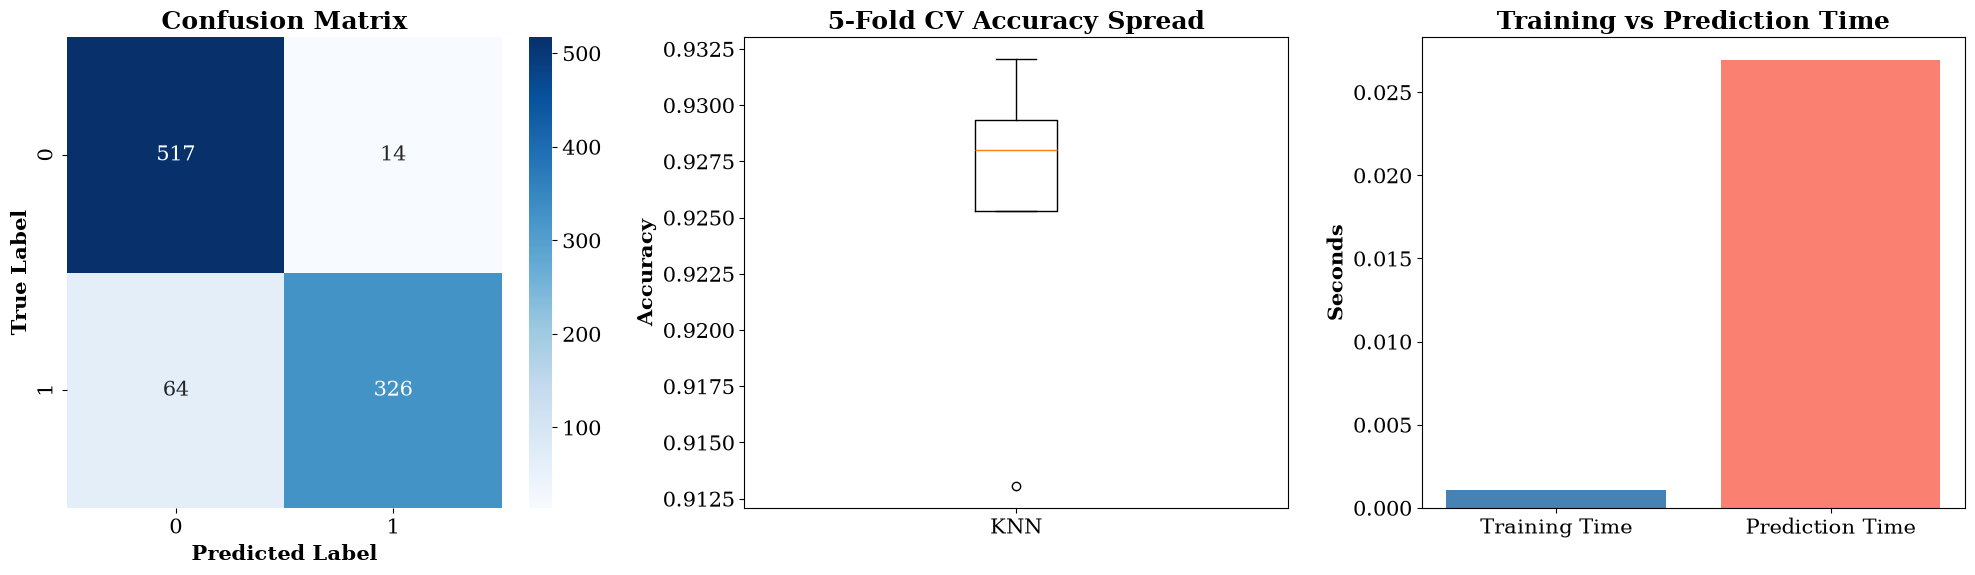

In [15]:
# Evaluation Plots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontweight="bold")
axes[0].set_ylabel("True Label", fontweight="bold")

# Plot 2: Cross Validation Score Spread
axes[1].boxplot(cv_scores)
axes[1].set_title("5-Fold CV Accuracy Spread", fontweight="bold")
axes[1].set_ylabel("Accuracy", fontweight="bold")
axes[1].set_xticklabels(["KNN"])

# Plot 3: Training vs Prediction Time
axes[2].bar(["Training Time", "Prediction Time"], [training_time, prediction_time], color=["steelblue", "salmon"])
axes[2].set_title("Training vs Prediction Time", fontweight="bold")
axes[2].set_ylabel("Seconds", fontweight="bold")

plt.tight_layout()
plt.savefig("./images/knn_evaluation_plots.eps", format="eps", dpi=600)
plt.show()

In [16]:
# ================================
# Summary Tables for Report
# ================================
import time
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import cross_val_score

# ---- 1. Naive Bayes Comparison ----
nb_models = {
    "Gaussian": (gnb, y_pred_gnb),
    "Multinomial": (mnb, y_pred_mnb),
    "Bernoulli": (bnb, y_pred_bnb),
}

nb_table = pd.DataFrame(index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])

for name, (model, y_pred) in nb_models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    y_proba = model.predict_proba(x_test)[:, 1]
    roc = roc_auc_score(y_test, y_proba)
    nb_table[name] = [acc, prec, rec, f1, roc]

print("Naive Bayes Comparison")
display(nb_table.round(4))


# ---- 2. KNN Comparison across k values ----
k_values = [1, 3, 5, 7, 9, 11]
knn_table = pd.DataFrame(index=k_values, columns=["Accuracy", "Precision", "Recall", "F1"])

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(x_train_scaled, y_train)
    y_pred_k = knn_k.predict(x_test_scaled)
    knn_table.loc[k] = [
        accuracy_score(y_test, y_pred_k),
        precision_score(y_test, y_pred_k),
        recall_score(y_test, y_pred_k),
        f1_score(y_test, y_pred_k),
    ]

knn_table.index.name = "k"
print("\nKNN Comparison")
display(knn_table.round(4))


# ---- 3. Grid Search vs Randomized Search ----
start = time.time()
grid_search.fit(x_train_scaled, y_train)
grid_time = time.time() - start

start = time.time()
random_search.fit(x_train_scaled, y_train)
random_time = time.time() - start

search_table = pd.DataFrame({
    "GridSearchCV": [
        grid_search.best_params_['n_neighbors'],
        grid_search.best_params_['metric'],
        grid_search.best_params_['weights'],
        "auto",
        grid_search.best_score_,
        grid_time,
    ],
    "RandomizedSearchCV": [
        random_search.best_params_['n_neighbors'],
        random_search.best_params_['metric'],
        random_search.best_params_['weights'],
        "auto",
        random_search.best_score_,
        random_time,
    ],
}, index=["Best k", "Metric", "Weights", "Algorithm", "CV Accuracy", "Execution Time"])

print("\nGrid Search vs Randomized Search")
display(search_table)


# ---- 4. KDTree vs BallTree ----
tree_table = pd.DataFrame(index=["Accuracy", "Training Time", "Prediction Time"])

for algo_name, algo in [("KDTree", "kd_tree"), ("BallTree", "ball_tree")]:
    knn_algo = KNeighborsClassifier(n_neighbors=5, algorithm=algo)

    start = time.time()
    knn_algo.fit(x_train_scaled, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred_algo = knn_algo.predict(x_test_scaled)
    pred_time = time.time() - start

    acc = accuracy_score(y_test, y_pred_algo)
    tree_table[algo_name] = [acc, train_time, pred_time]

print("\nKDTree vs BallTree")
display(tree_table.round(6))


# ---- 5. Cross Validation: Naive Bayes vs Best KNN ----
# pick best-performing Naive Bayes model based on accuracy from the comparison table above
best_nb_name = nb_table.loc["Accuracy"].idxmax()
best_nb_model = nb_models[best_nb_name][0]

nb_cv_scores = cross_val_score(best_nb_model, x_train_scaled, y_train, cv=5, scoring='accuracy')
knn_cv_scores = cv_scores  # already computed for best_knn in the "5 Fold Cross Validation" cell

cv_table = pd.DataFrame({
    "Naive Bayes": list(nb_cv_scores) + [nb_cv_scores.mean()],
    "Best KNN": list(knn_cv_scores) + [knn_cv_scores.mean()],
}, index=["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5", "Average"])

print(f"\nCross Validation (Best Naive Bayes = {best_nb_name})")
display(cv_table.round(4))


# ---- 6. Theoretical Time Complexity (fixed reference table, not computed from data) ----
complexity_table = pd.DataFrame({
    "Training": ["O(nd)", "O(1)", "O(nd log n)", "O(nd log n)"],
    "Prediction": ["O(d)", "O(nd)", "O(log n) avg", "O(log n) avg"],
}, index=["Naive Bayes", "KNN (Brute)", "KDTree", "BallTree"])

print("\nTheoretical Time Complexity")
display(complexity_table)


# ---- 7. Experimental Time Analysis ----
exp_time_table = pd.DataFrame(index=["Training(s)", "Prediction(s)"])

nb_timed_models = {
    "Gaussian NB": GaussianNB(),
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB(),
}

for name, model in nb_timed_models.items():
    start = time.time()
    model.fit(x_train, y_train)
    train_t = time.time() - start

    start = time.time()
    model.predict(x_test)
    pred_t = time.time() - start

    exp_time_table[name] = [train_t, pred_t]

# Best KNN timing reuses training_time / prediction_time from the earlier timing cell
exp_time_table["Best KNN"] = [training_time, prediction_time]

exp_time_table = exp_time_table.T
exp_time_table.columns = ["Training(s)", "Prediction(s)"]

print("\nExperimental Time Analysis")
display(exp_time_table.round(6))


Naive Bayes Comparison


,Gaussian,Multinomial,Bernoulli
Accuracy,0.8208,0.7861,0.8806
Precision,0.7193,0.7644,0.9070
Recall,0.9462,0.7154,0.8000
F1,0.8173,0.7391,0.8501
ROC-AUC,0.9419,0.8639,0.9555



KNN Comparison


,Accuracy,Precision,Recall,F1
k,,,,
1,0.893594,0.874359,0.874359,0.874359
3,0.891422,0.883598,0.85641,0.869792
5,0.893594,0.898907,0.84359,0.87037
7,0.89468,0.912676,0.830769,0.869799
9,0.890337,0.904762,0.828205,0.864793
11,0.896851,0.917847,0.830769,0.87214



Grid Search vs Randomized Search


...

,Naive Bayes,Best KNN
Fold 1,0.9117,0.9293
Fold 2,0.8804,0.9130
Fold 3,0.9076,0.9280
Fold 4,0.9008,0.9321
Fold 5,0.9035,0.9253
Average,0.9008,0.9255



Theoretical Time Complexity


,Training,Prediction
Naive Bayes,O(nd),O(d)
KNN (Brute),O(1),O(nd)
KDTree,O(nd log n),O(log n) avg
BallTree,O(nd log n),O(log n) avg



Experimental Time Analysis


,Training(s),Prediction(s)
Gaussian NB,0.003244,0.000930
Multinomial NB,0.001834,0.000648
Bernoulli NB,0.002804,0.001012
Best KNN,0.001100,0.026953
